# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [ ]:
df = pd.read_csv('/content/heart (1).csv')
df.head()

# cp - chest pain
# trestbps - blood  pressure in resting condition
# chol - cholestrol level
# fbs - fasting blood sugar level
# restecg - (electrocardio graphy)
# thalach - mxinum heart rate acheived during the test

# oldpeak - how much ecg changes
# slope - slope of ecg

# ca - the number of major blood vessels
# thal -  a blood disorder tht can damge the heart

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


# EDA

In [ ]:
# EDA

df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df['target'].value_counts()

,count
target,
1,165
0,138


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.duplicated().sum()

np.int64(0)

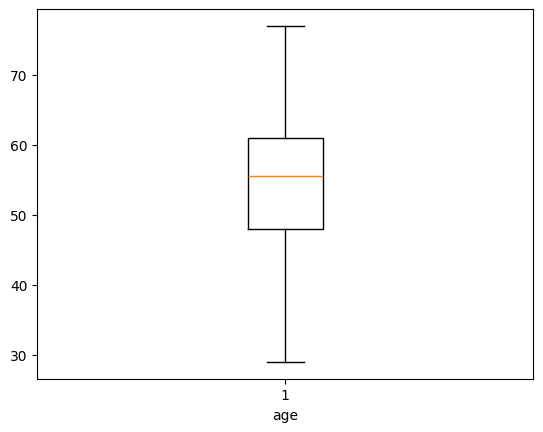

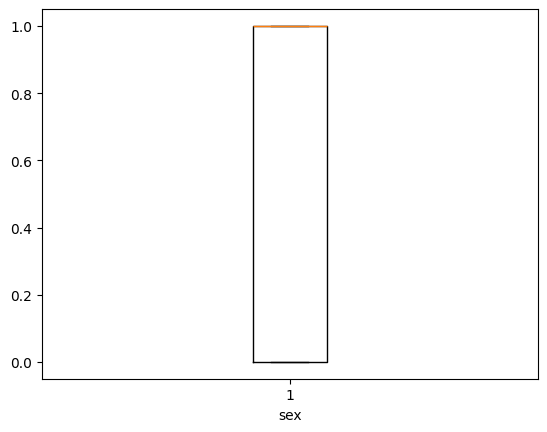

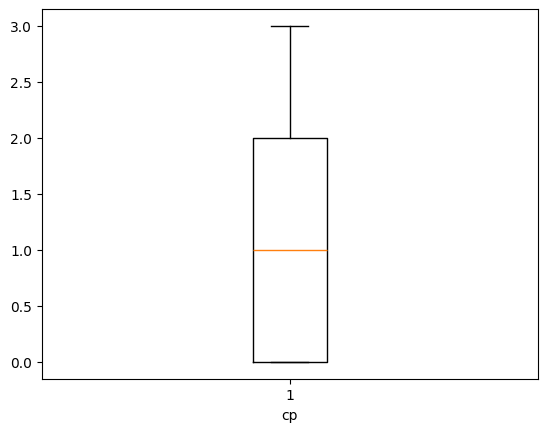

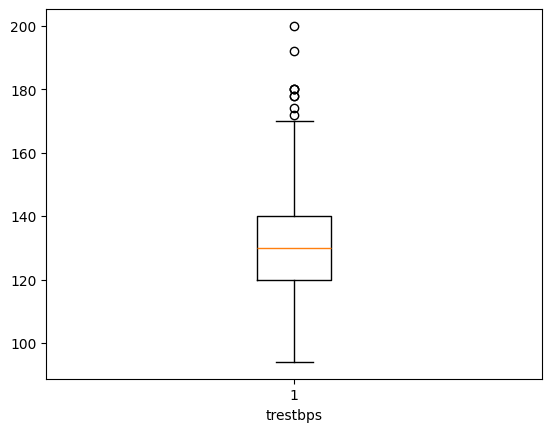

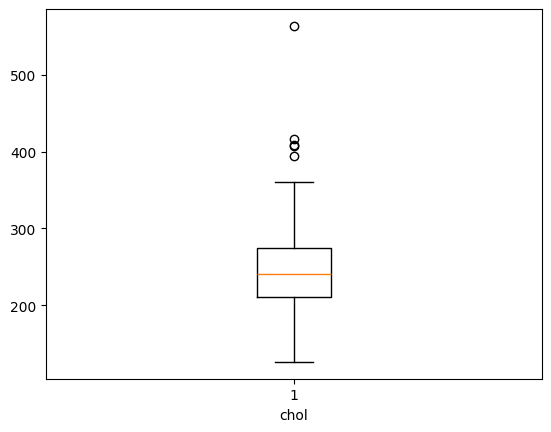

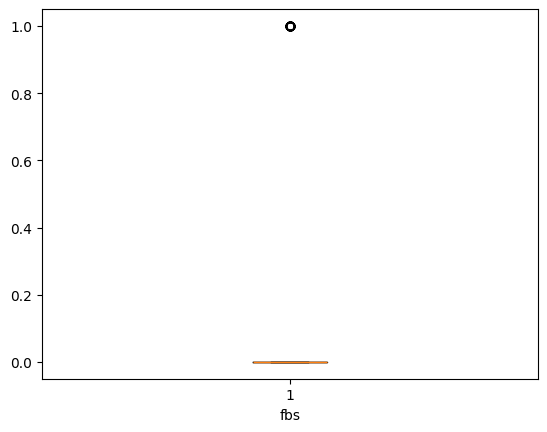

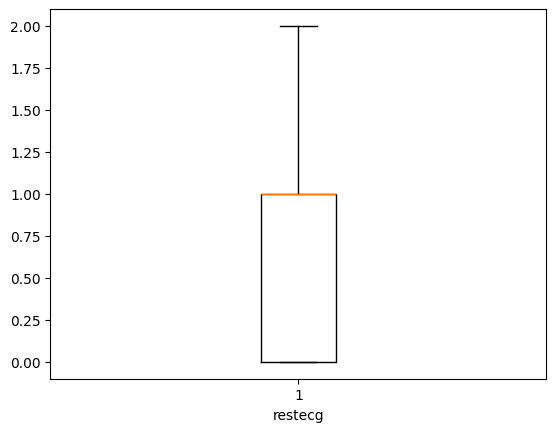

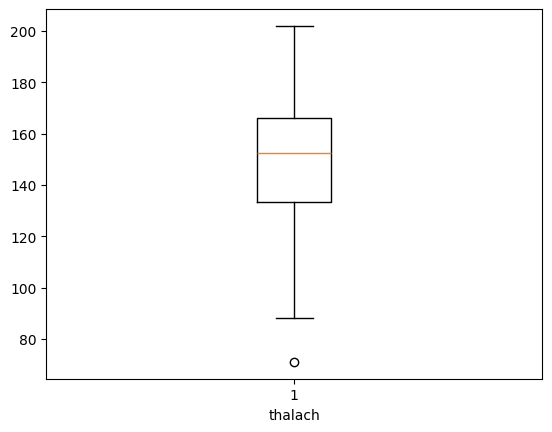

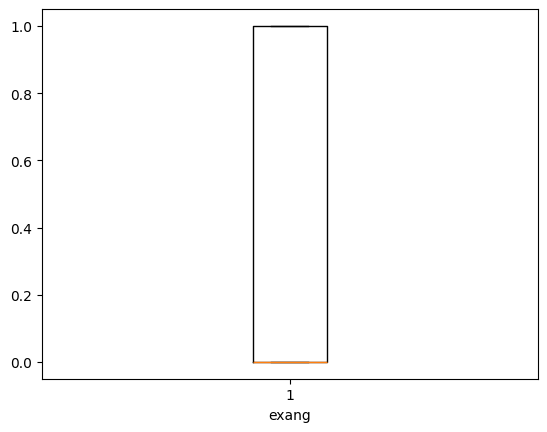

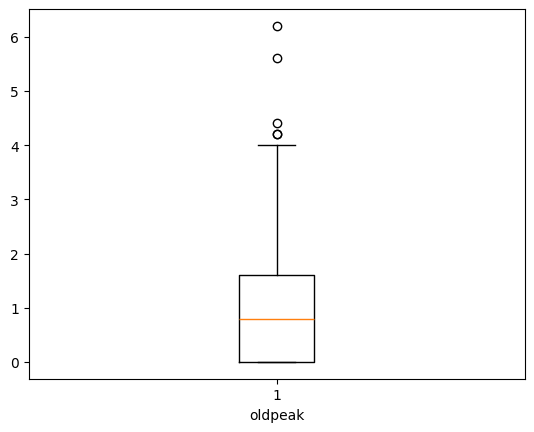

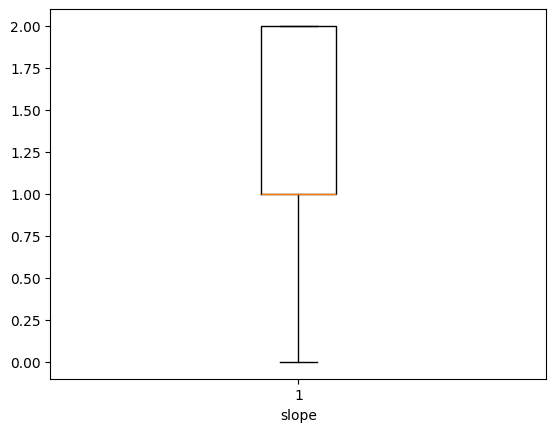

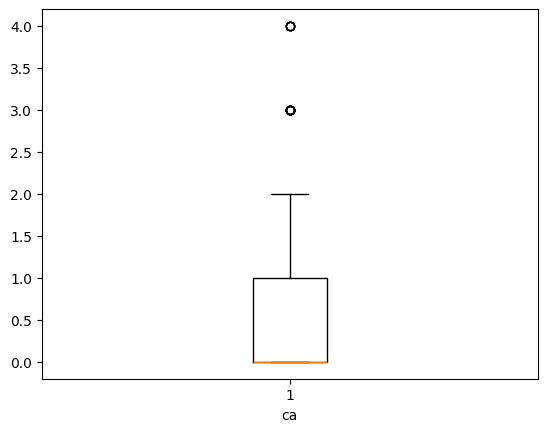

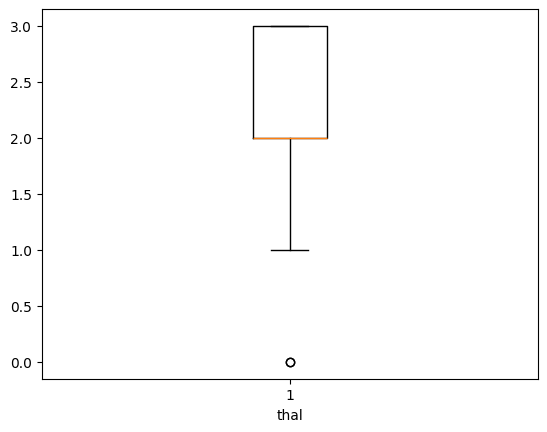

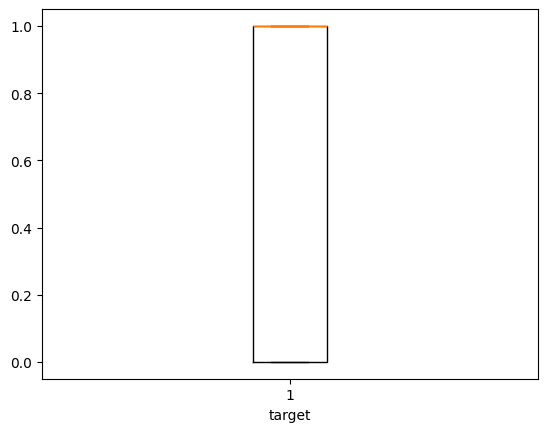

In [ ]:
for col in df.columns:
  if df[col].dtype != 'object':
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
# reason for not removing the outliers:

#  unlike algorithms like linear regression or kmeans , decisison trees are not sensitive to outliers
# decision tree split the data based on the feature to form branches
# the focus is not actual values but on how well the spit separtes the target classes

<Axes: >

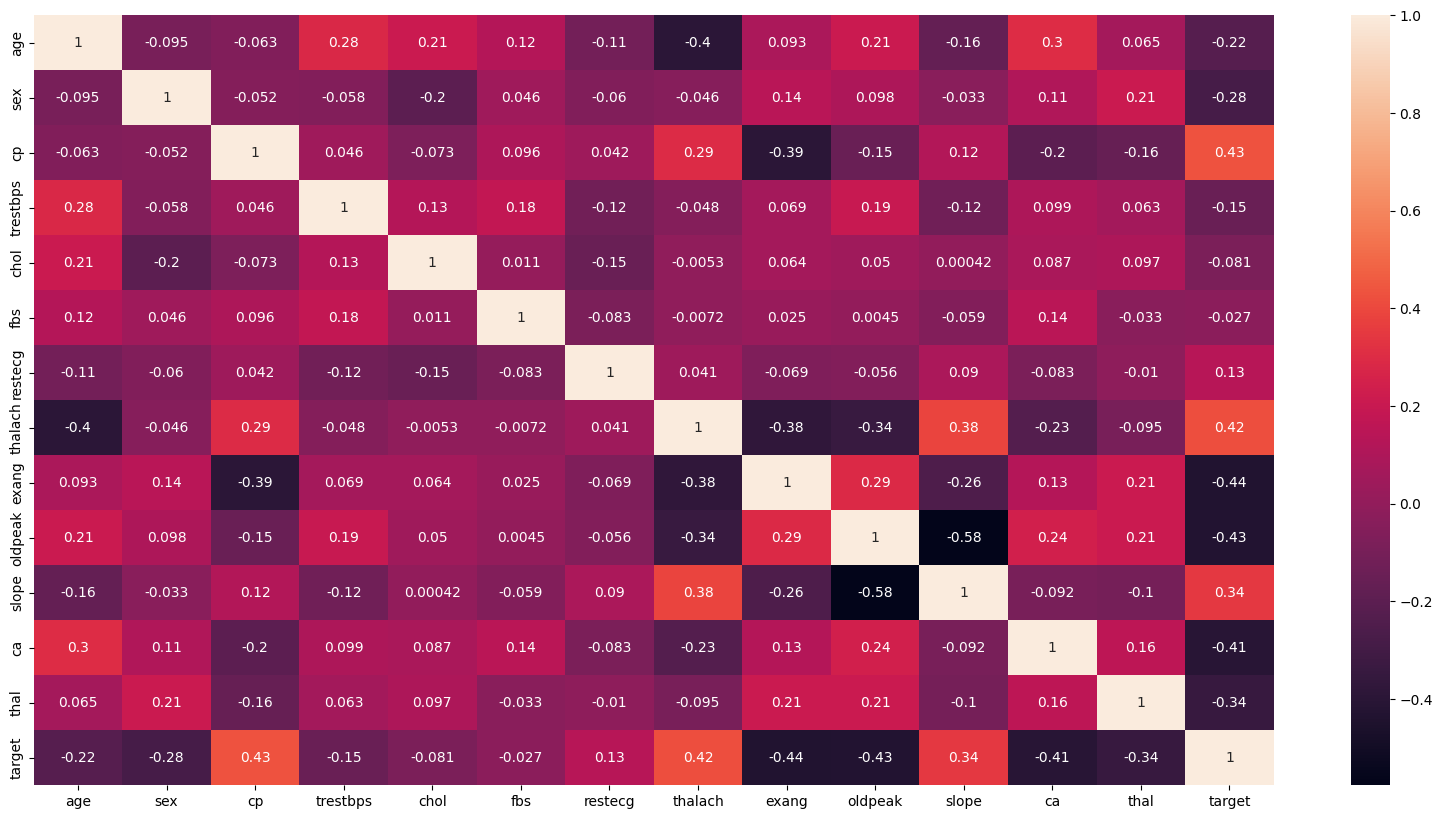

In [ ]:
# check for correlation

plt.figure(figsize = (20,10))
sns.heatmap(df.corr(), annot = True)

# Model Building

In [ ]:
# model building

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.tree import DecisionTreeClassifier

In [ ]:
x = df.drop(columns = ['target'])
y = df['target']

In [ ]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [ ]:
y

,target
0,1
1,1
2,1
3,1
4,1
...,...
298,0
299,0
300,0
301,0


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 45)

In [ ]:
model = DecisionTreeClassifier()

In [ ]:
model.fit(x_train, y_train)

DecisionTreeClassifier()

# Evaluation

In [ ]:
y_pred = model.predict(x_test)
y_pred

array([0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1])

In [ ]:
compare = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(compare)

     Actual  Predicted
165       0          0
99        1          1
80        1          1
113       1          0
138       1          0
..      ...        ...
229       0          0
191       0          0
115       1          1
219       0          1
122       1          1

[61 rows x 2 columns]


In [ ]:
accuracy_score(y_pred, y_test)*100

77.04918032786885

In [ ]:
cm = confusion_matrix(y_pred, y_test)
cm

array([[21,  8],
       [ 6, 26]])

[Text(0.5165441176470589, 0.9444444444444444, 'x[2] <= 0.5\ngini = 0.497\nsamples = 241\nvalue = [111, 130]'),
 Text(0.24019607843137256, 0.8333333333333334, 'x[11] <= 0.5\ngini = 0.396\nsamples = 114\nvalue = [83, 31]'),
 Text(0.37837009803921573, 0.8888888888888888, 'True  '),
 Text(0.14705882352941177, 0.7222222222222222, 'x[12] <= 2.5\ngini = 0.5\nsamples = 55\nvalue = [28.0, 27.0]'),
 Text(0.0784313725490196, 0.6111111111111112, 'x[8] <= 0.5\ngini = 0.397\nsamples = 33\nvalue = [9, 24]'),
 Text(0.0392156862745098, 0.5, 'x[7] <= 96.5\ngini = 0.172\nsamples = 21\nvalue = [2, 19]'),
 Text(0.0196078431372549, 0.3888888888888889, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.058823529411764705, 0.3888888888888889, 'x[4] <= 316.5\ngini = 0.095\nsamples = 20\nvalue = [1, 19]'),
 Text(0.0392156862745098, 0.2777777777777778, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]'),
 Text(0.0784313725490196, 0.2777777777777778, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.11764705882352941

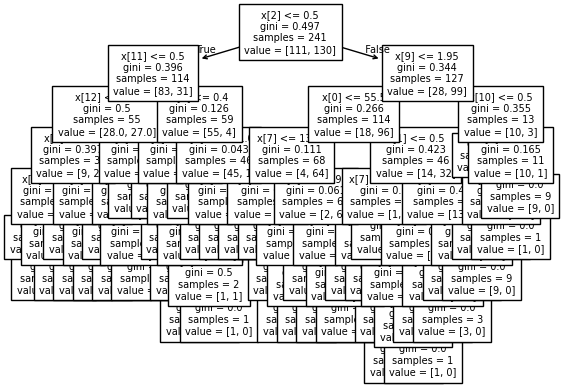

In [ ]:
from sklearn import tree
tree.plot_tree (model , fontsize = 7)

# Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

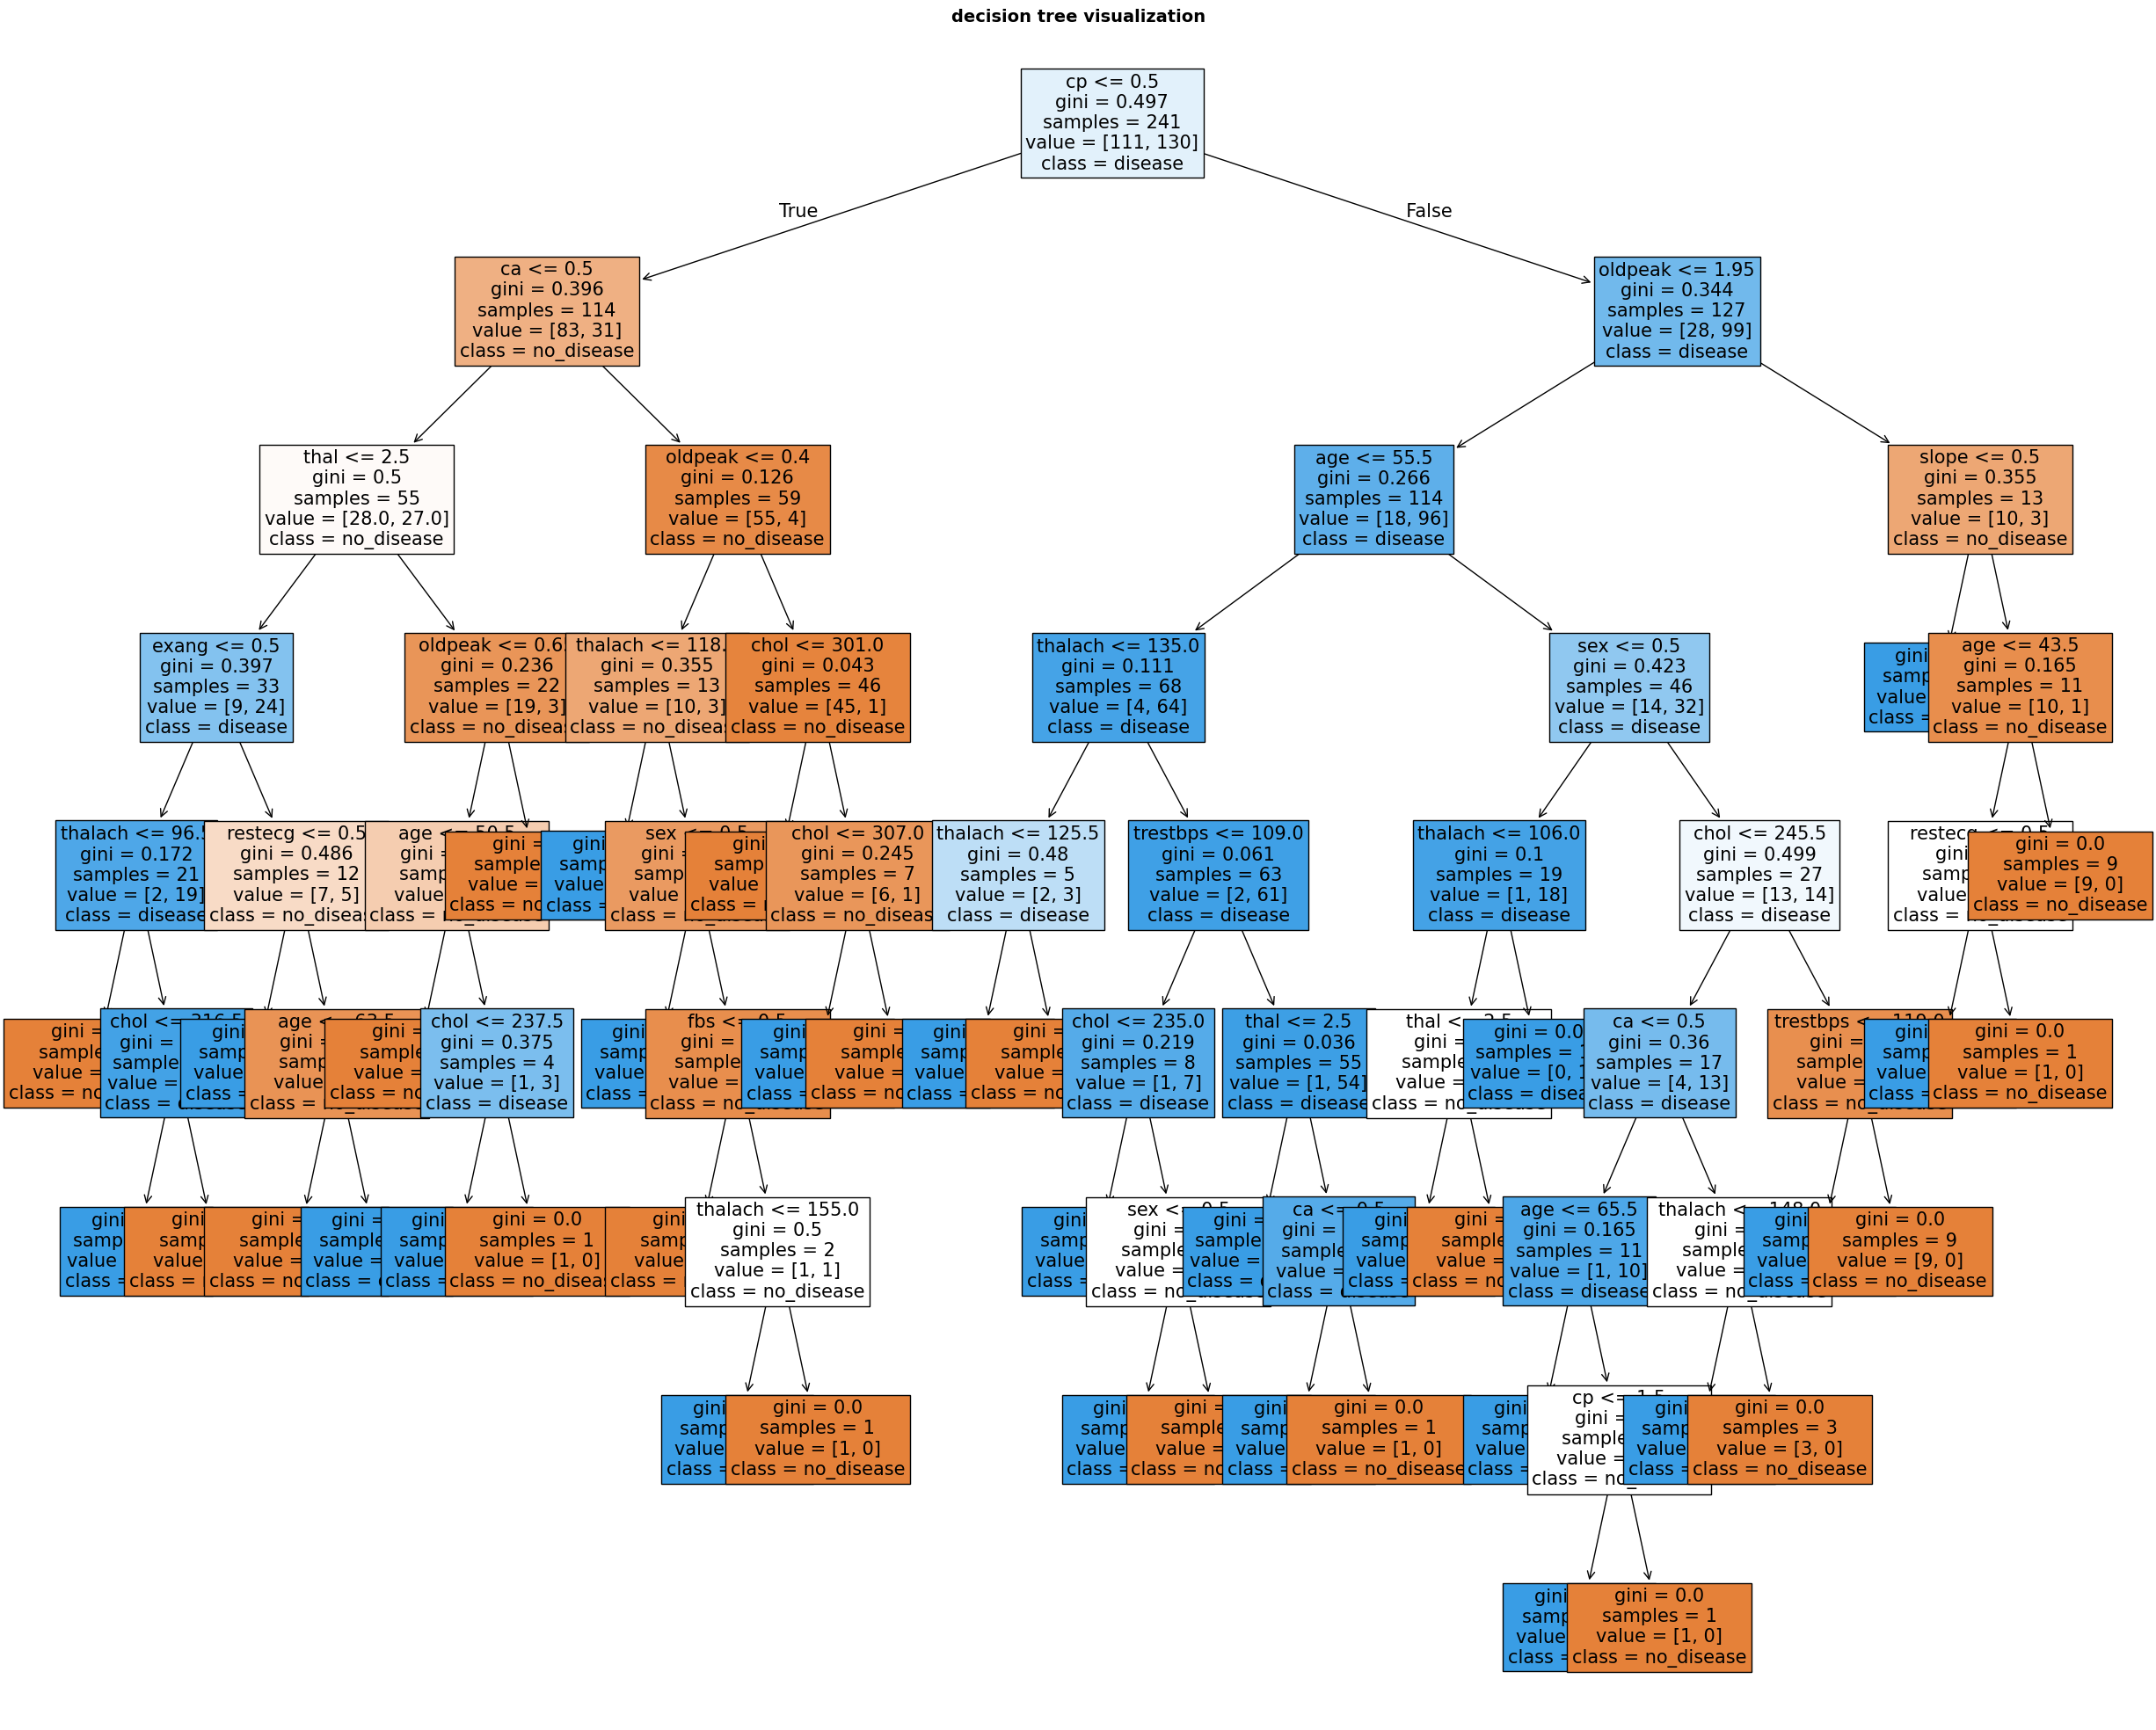

In [ ]:
plt.figure(figsize = (30, 25))
tree.plot_tree (model,
                feature_names = x_train.columns,
                class_names = ['no_disease', 'disease'],
                filled = True,
                fontsize = 15)
plt.title('decision tree visualization', fontsize = 14, fontweight = 'bold')
plt.show

In [ ]:
x_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
165,67,1,0,160,286,0,0,108,1,1.5,1,3,2
99,53,1,2,130,246,1,0,173,0,0.0,2,3,2
80,41,1,2,112,250,0,1,179,0,0.0,2,0,2
113,43,1,0,110,211,0,1,161,0,0.0,2,0,3
138,57,1,0,110,201,0,1,126,1,1.5,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,64,1,2,125,309,0,1,131,1,1.8,1,0,3
191,58,1,0,128,216,0,0,131,1,2.2,1,3,3
115,37,0,2,120,215,0,1,170,0,0.0,2,0,2
219,48,1,0,130,256,1,0,150,1,0.0,2,2,3


In [ ]:
# checking a data from x_test we took the 165th row

[67.0, 1.0, 0.0, 160.0, 286.0, 0.0, 0.0, 108.0, 1.0, 1.5, 1.0, 3.0, 2.0]

row_values = x_test.iloc[0].to_list()
new_data = [row_values]

predictions = model.predict(new_data)
predictions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
# array[0] means the person had no disease

In [ ]:
# Entropy and gini impurity both measures impurity and usually give very similar split

# gini impurity is slightly faster as compared to entropy

In [ ]:
# max_depth -> is a parameter that defines the maximum no. of levels
# your decision tree is allowed to grow

# prevent overfitting: if a tree is too deep it learns the training data well and perform badly on the testing data

# limiting max_depth -> speed up training process

# shallow tree are easier to understand and interpret

In [ ]:
depth = [1,2,3,4,5,6,7,8,9,10,11,12,13]

for i in depth:
  model = DecisionTreeClassifier(max_depth = i, random_state =43)
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  acc = accuracy_score(y_test, y_pred)
  print(f"maxdepth {i} accuray score {acc}")

maxdepth 1 accuray score 0.7704918032786885
maxdepth 2 accuray score 0.7213114754098361
maxdepth 3 accuray score 0.8360655737704918
maxdepth 4 accuray score 0.7868852459016393
maxdepth 5 accuray score 0.819672131147541
maxdepth 6 accuray score 0.819672131147541
maxdepth 7 accuray score 0.8360655737704918
maxdepth 8 accuray score 0.8360655737704918
maxdepth 9 accuray score 0.8360655737704918
maxdepth 10 accuray score 0.8360655737704918
maxdepth 11 accuray score 0.8360655737704918
maxdepth 12 accuray score 0.8360655737704918
maxdepth 13 accuray score 0.8360655737704918


In [ ]:
# after 7 the maximum accuracy remains the same

model.get_depth()  # gives the optimal max depth of your model

8

# Hyperparameter tuning

In ML, the hyperparameter is a setting you choosing before training a model

Why it is called tuning?

Without tuning, model might underfit and overfit so tuning helps us balance the model


### Two common types of hyperparameter tuning

1. GridSearchCv : try all possible combination of given hperparameter values

How it works?

You give a list of parameter

It tries every possible combination

Pick the best one with best performance


2. RandomizedSearchCv : it randomly picks a few combination

How it works?

You definded a range of parameters

It tries only a fixed no. of random comination

Faster than GridSearchCv

### Parameters

1. max_depth - maximum depth of the tree

2. min_smaple_split - minimum no. of sample required to split a node

3. min_sample_leaf - minimum no. of sample requuired to be at a leaf (final desicion)

4. criteria - metric used to measure the quality of split (gini or entropy)

5. max_features - no. of features consider when looking for a best split



In [ ]:
from sklearn.model_selection import GridSearchCV

new_model = DecisionTreeClassifier()

grid_params = {'criterion':['gini','entropy'], 'max_depth':[1,5,50,100],
               'random_state': [0,1,3,4,5], 'min_samples_split':[2,6,8,3,9,5,22],
               'min_samples_leaf': [1,4,6,7,9], 'max_features':[3,5,7,9]}


## Cross Validation

CV - stands for cross_validation

It is technique used to evalueate the model performance more accurately

Instead of splitting inot one train_test_split. We split it multiple times



In [ ]:
gv = GridSearchCV(estimator = new_model, param_grid = grid_params, cv = 3)

In [ ]:
gv.fit(x_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 5, 50, 100],
                         'max_features': [3, 5, 7, 9],
                         'min_samples_leaf': [1, 4, 6, 7, 9],
                         'min_samples_split': [2, 6, 8, 3, 9, 5, 22],
                         'random_state': [0, 1, 3, 4, 5]})

In [ ]:
gv.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 3,
 'min_samples_leaf': 9,
 'min_samples_split': 2,
 'random_state': 4}

In [ ]:
gv.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 3,
 'min_samples_leaf': 9,
 'min_samples_split': 2,
 'random_state': 4}

In [ ]:
dt_model = gv.best_estimator_

In [ ]:
y_pred_1 = dt_model.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred_1)

0.7868852459016393

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
new_model1 = DecisionTreeClassifier()

grid_params = {'criterion':['gini','entropy'], 'max_depth':[1,5,7,8,50,100],
               'random_state': [0,1,3,4,5,40,45], 'min_samples_split':[2,6,8,3,9,5,22,20],
               'min_samples_leaf': [1,4,6,7,9,10]}

In [ ]:
rv = RandomizedSearchCV(estimator = new_model1,
                        param_distributions = grid_params,
                        n_iter = 20,
                        cv = 3,
                        random_state = 42,
                        n_jobs = -1)

In [ ]:
rv.fit(x_train, y_train)

RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [1, 5, 7, 8, 50, 100],
                                        'min_samples_leaf': [1, 4, 6, 7, 9, 10],
                                        'min_samples_split': [2, 6, 8, 3, 9, 5,
                                                              22, 20],
                                        'random_state': [0, 1, 3, 4, 5, 40,
                                                         45]},
                   random_state=42)

In [ ]:
rv.best_params_

{'random_state': 45,
 'min_samples_split': 2,
 'min_samples_leaf': 9,
 'max_depth': 8,
 'criterion': 'gini'}

In [ ]:
dt_model_1 = rv.best_estimator_


In [ ]:
y_pred_2 = dt_model_1.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred_2)

0.8032786885245902